<a href="https://colab.research.google.com/github/Akshatha7710/RAG-based-Document-Question-Answering-System-using-LangChain-FAISS-and-LLMs/blob/main/Question%20Answering%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG-Based Document Question Answering System v7
**Stack:** PyMuPDF · python-docx · ChromaDB (persistent) · Sentence-Transformers · Gemini 2.5 Flash


In [1]:
# Cell 1: Install Dependencies
!pip install -q pymupdf python-docx chromadb sentence-transformers \
               langchain-text-splitters google-generativeai tqdm nltk matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6

In [2]:
# Cell 2: Set API Key
import os
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")
if not api_key or len(api_key) < 10:
    raise ValueError(
        "❌ GEMINI_API_KEY secret is missing or looks invalid.\n"
        "Add it via Colab Secrets (🔑 icon in the left sidebar)."
    )

os.environ["GEMINI_API_KEY"] = api_key
print("✅ API Key loaded:", api_key[:10], "...")

✅ API Key loaded: AIzaSyDFX_ ...


In [3]:
# Cell 3: Imports & Setup
import fitz
import docx
import chromadb
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
import time, os, threading

# ── Central configuration ──────────────────────────────────────────
CONFIG = {
    "model":              "gemini-2.5-flash",
    "embedder":           "all-MiniLM-L6-v2",
    "chunk_size":         500,
    "chunk_overlap":      100,
    "top_k":              5,
    "relevance_threshold":0.35,
    "db_path":            "/content/chroma_db",
    "max_retries":        5,
    "rpm_limit":          10,
}

# ── Gemini ────────────────────────────────────────────────────────
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
llm = genai.GenerativeModel(CONFIG["model"])

# ── Embedding model ───────────────────────────────────────────────
embedder = SentenceTransformer(CONFIG["embedder"])

# ── Persistent vector database ────────────────────────────────────
# For true persistence across sessions, mount Drive and set db_path:
#   from google.colab import drive; drive.mount('/content/drive')
#   CONFIG['db_path'] = "/content/drive/MyDrive/rag_chroma_db"
chroma     = chromadb.PersistentClient(path=CONFIG["db_path"])
collection = chroma.get_or_create_collection("docs", metadata={"hnsw:space": "cosine"})

# ── Text splitter ─────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG["chunk_size"],
    chunk_overlap=CONFIG["chunk_overlap"],
)

# ── Token-bucket rate limiter (avoids hard sleep between calls) ───
class RateLimiter:
    """Allow at most `rpm` calls per 60 seconds."""
    def __init__(self, rpm: int):
        self.interval = 60.0 / rpm
        self._lock     = threading.Lock()
        self._last     = 0.0

    def wait(self):
        with self._lock:
            now  = time.monotonic()
            gap  = self.interval - (now - self._last)
            if gap > 0:
                time.sleep(gap)
            self._last = time.monotonic()

_rate_limiter = RateLimiter(CONFIG["rpm_limit"])

print(f"✅ All components initialized")
print(f"📂 Vector DB path: {CONFIG['db_path']}")
print(f"📄 Documents already in collection: {collection.count()}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ All components initialized
📂 Vector DB path: /content/chroma_db
📄 Documents already in collection: 0


In [4]:
# Cell 4: Core Functions

# ── Streaming Gemini call ─────────────────────────────────────────
def call_gemini(prompt: str, stream: bool = True,
                max_attempts: int = CONFIG["max_retries"]) -> str:
    """
    Call Gemini with exponential backoff.
    stream=True: tokens print live and full text is returned.
    stream=False: returns text silently.
    """
    for attempt in range(max_attempts):
        try:
            _rate_limiter.wait()
            if stream:
                chunks_out = []
                for chunk in llm.generate_content(prompt, stream=True):
                    print(chunk.text, end="", flush=True)
                    chunks_out.append(chunk.text)
                print()
                return "".join(chunks_out)
            else:
                return llm.generate_content(prompt).text
        except Exception as e:
            if attempt == max_attempts - 1:
                return f"❌ Failed after {max_attempts} attempts: {e}"
            wait = 2 ** attempt * 5
            print(f"⚠️  Attempt {attempt+1} failed — retrying in {wait}s… ({e})")
            time.sleep(wait)


# ── Text extraction (PDF, DOCX, TXT) ─────────────────────────────
def extract_text(path: str) -> str:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".pdf":
        doc  = fitz.open(path)
        text = "\n\n".join(page.get_text() for page in doc)
        doc.close()
        return text
    elif ext == ".docx":
        document = docx.Document(path)
        return "\n\n".join(p.text for p in document.paragraphs if p.text.strip())
    elif ext == ".txt":
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            return f.read()
    else:
        raise ValueError(f"Unsupported file type '{ext}'. Supported: .pdf, .docx, .txt")


# ── Ingestion ─────────────────────────────────────────────────────
def ingest_file(path: str):
    filename = os.path.basename(path)
    text     = extract_text(path)
    if not text.strip():
        print(f"⚠️  '{filename}' appears empty — skipping.")
        return
    chunks     = splitter.split_text(text)
    embeddings = embedder.encode(chunks, show_progress_bar=True).tolist()
    ids        = [f"{filename}_chunk_{i}" for i in range(len(chunks))]
    metadatas  = [{"source": filename, "chunk_index": i} for i in range(len(chunks))]
    collection.upsert(ids=ids, embeddings=embeddings, documents=chunks, metadatas=metadatas)
    print(f"✅ Ingested {len(chunks)} chunks from '{filename}'")


def ingest_multiple_files(paths: list):
    for path in tqdm(paths, desc="Ingesting files"):
        ingest_file(path)
    print(f"\n📚 Total chunks in DB: {collection.count()}")


ingest_pdf           = ingest_file
ingest_multiple_pdfs = ingest_multiple_files


# ── Delete a source ───────────────────────────────────────────────
def delete_source(filename: str):
    results = collection.get(where={"source": filename}, include=["metadatas"])
    ids_to_delete = results["ids"]
    if not ids_to_delete:
        print(f"⚠️  No chunks found for '{filename}'. Check with list_sources().")
        return
    collection.delete(ids=ids_to_delete)
    print(f"🗑️  Deleted {len(ids_to_delete)} chunks from '{filename}'")


# ── Utilities ─────────────────────────────────────────────────────
def list_sources():
    total = collection.count()
    if total == 0:
        print("⚠️  Vector store is empty. Run Cell 5 first.")
        return
    all_meta = collection.get(include=["metadatas"])["metadatas"]
    sources  = {}
    for m in all_meta:
        src = m.get("source", "unknown")
        sources[src] = sources.get(src, 0) + 1
    print(f"📚 {total} total chunks from {len(sources)} file(s):")
    for src, count in sorted(sources.items()):
        print(f"   • {src}  ({count} chunks)")


def _require_documents():
    if collection.count() == 0:
        raise RuntimeError(
            "❌ No documents in the vector store.\n"
            "Run Cell 5 to upload and ingest documents first."
        )


# ── Retrieval with relevance filter ──────────────────────────────
def _retrieve(question: str, top_k: int):
    q_emb   = embedder.encode([question]).tolist()
    results = collection.query(
        query_embeddings=q_emb,
        n_results=top_k,
        include=["documents", "distances", "metadatas"]
    )
    chunks, scores, metadatas = (
        results["documents"][0],
        results["distances"][0],
        results["metadatas"][0],
    )
    threshold = CONFIG["relevance_threshold"]
    filtered  = [(c, s, m) for c, s, m in zip(chunks, scores, metadatas) if s <= threshold]
    if not filtered:
        filtered = [(chunks[0], scores[0], metadatas[0])]
    f_chunks, f_scores, f_meta = zip(*filtered)
    context = "\n\n---\n\n".join(f_chunks)
    return context, list(f_chunks), list(f_scores), list(f_meta)


# ── Confidence tag ────────────────────────────────────────────────
def _confidence_tag(scores: list) -> str:
    """
    Derive a confidence level from avg cosine distance of retrieved chunks.
    Distance 0 = perfect match, 1 = completely dissimilar.
    """
    avg_dist = sum(scores) / len(scores)
    if avg_dist <= 0.20:  return "[🟢 High confidence]"
    if avg_dist <= 0.35:  return "[🟡 Medium confidence]"
    return "[🔴 Low confidence — answer may not reflect document]"


# ── Single-turn QA ────────────────────────────────────────────────
def ask(question: str, top_k: int = CONFIG["top_k"],
        show_sources: bool = True, stream: bool = True) -> str:
    """Retrieve relevant chunks and stream a grounded answer with a confidence tag."""
    _require_documents()
    context, chunks, scores, metadatas = _retrieve(question, top_k)

    prompt = (
        "Answer the question using ONLY the context below.\n"
        "If the answer is not in the context, say 'I don\'t have enough information to answer that.'.\n\n"
        f"CONTEXT:\n{context}\n\nQUESTION:\n{question}"
    )

    if stream:
        print("🤖 ", end="")
    answer = call_gemini(prompt, stream=stream)
    print(_confidence_tag(scores))

    if show_sources:
        print("─" * 60)
        print("📄 SOURCE CHUNKS USED:")
        for i, (chunk, score, meta) in enumerate(zip(chunks, scores, metadatas)):
            similarity = round((1 - score) * 100, 1)
            print(f"\n[{i+1}] {similarity}% match | {meta.get('source', 'unknown')}")
            print(chunk[:300] + "..." if len(chunk) > 300 else chunk)
        print("─" * 60)

    return answer


# ── Document summary ─────────────────────────────────────────────
def summarize_document(source: str = None, style: str = "bullets") -> str:
    """
    Summarize all (or a specific) ingested document.
    style: 'bullets' | 'paragraph' | 'tldr'
    Example: summarize_document()                    # all docs
             summarize_document('report.pdf')        # one doc
             summarize_document(style='tldr')        # one-liner
    """
    _require_documents()
    if source:
        res  = collection.get(where={"source": source}, include=["documents"])
        docs = res["documents"]
    else:
        res  = collection.get(include=["documents"])
        docs = res["documents"]

    if not docs:
        print(f"⚠️  No chunks found for '{source}'.")
        return ""

    # Sample up to 30 chunks evenly to stay within token limits
    import math
    step    = max(1, math.ceil(len(docs) / 30))
    sampled = docs[::step][:30]
    context = "\n\n".join(sampled)

    style_instruction = {
        "bullets":   "Summarize in 5–7 concise bullet points.",
        "paragraph": "Summarize in 2–3 coherent paragraphs.",
        "tldr":      "Give a single TL;DR sentence.",
    }.get(style, "Summarize in 5–7 bullet points.")

    prompt = (
        f"You are summarizing a document. {style_instruction}\n"
        "Use ONLY the content below. Do not add external knowledge.\n\n"
        f"DOCUMENT CONTENT:\n{context}"
    )
    print(f"📝 Summary ({style}):")
    return call_gemini(prompt, stream=True)


# ── Conversational RAG chat ───────────────────────────────────────
class RAGChat:
    """
    Stateful chat with memory, streaming, and per-turn confidence tags.
    """
    def __init__(self, top_k: int = CONFIG["top_k"], max_history_turns: int = 6):
        self.top_k = top_k
        self.max_history_turns = max_history_turns
        self.history: list = []

    def chat(self, user_message: str, show_sources: bool = False,
             stream: bool = True) -> str:
        _require_documents()
        context, chunks, scores, metadatas = _retrieve(user_message, self.top_k)

        history_str = ""
        for turn in self.history[-(self.max_history_turns * 2):]:
            role = "User" if turn["role"] == "user" else "Assistant"
            history_str += f"{role}: {turn['content']}\n"

        prompt = (
            "You are a helpful assistant. Answer using ONLY the context provided.\n"
            "If the answer is not in the context, say 'I don\'t have enough information to answer that.'.\n"
            "Use conversation history for follow-up questions.\n\n"
            f"CONTEXT FROM DOCUMENTS:\n{context}\n\n"
            f"CONVERSATION HISTORY:\n{history_str}\n"
            f"User: {user_message}\nAssistant:"
        )

        if stream:
            print("🤖 ", end="")
        answer = call_gemini(prompt, stream=stream)
        print(_confidence_tag(scores))

        self.history.append({"role": "user",      "content": user_message})
        self.history.append({"role": "assistant", "content": answer})

        if show_sources:
            print("─" * 60)
            for i, (chunk, score, meta) in enumerate(zip(chunks, scores, metadatas)):
                similarity = round((1 - score) * 100, 1)
                print(f"[{i+1}] {similarity}% | {meta.get('source', 'unknown')}")
            print("─" * 60)

        return answer

    def reset(self):
        self.history = []
        print("🔄 Conversation history cleared.")


print("✅ Functions ready")

✅ Functions ready


In [5]:
# Cell 5: Upload & Ingest Documents
# Supports: .pdf  .docx  .txt
from google.colab import files

uploaded = files.upload()   # opens file picker
ingest_multiple_files(list(uploaded.keys()))
list_sources()

Saving ai_basics.pdf to ai_basics.pdf


Ingesting files:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Ingesting files: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]

✅ Ingested 13 chunks from 'ai_basics.pdf'

📚 Total chunks in DB: 13
📚 13 total chunks from 1 file(s):
   • ai_basics.pdf  (13 chunks)


In [6]:
# Cell 6: Single-Turn Q&A
# Answers stream token-by-token. The rate limiter handles pacing automatically.
questions = [
    "What are the three types of machine learning?",
    "How is AI used in healthcare?",
    "What are the ethical concerns around AI?",
    "What is the difference between deep learning and machine learning?",
]

for q in questions:
    print("\n" + "="*60)
    print(f"Q: {q}")
    ask(q, show_sources=False)


Q: What are the three types of machine learning?
🤖 I don't have enough information to answer that.
[🟡 Medium confidence]

Q: How is AI used in healthcare?
🤖 I don't have enough information to answer that.
[🔴 Low confidence — answer may not reflect document]

Q: What are the ethical concerns around AI?
🤖 The ethical concerns around AI include data collection and surveillance, the impact of automation on employment, and the challenge of making AI systems explainable and transparent.
[🟡 Medium confidence]

Q: What is the difference between deep learning and machine learning?
🤖 Deep Learning is a subset of machine learning.
[🔴 Low confidence — answer may not reflect document]


In [7]:
# Cell 7: Ask Your Own Question / Summarize

# ── Option A: single question ────────────────────────────────────
my_question = "Summarize the document in 3 bullet points"  # ← change this
print(f"Q: {my_question}")
ask(my_question)

# ── Option B: one-call document summary ──────────────────────────
# summarize_document()                     # bullets (default)
# summarize_document(style='paragraph')
# summarize_document(style='tldr')
# summarize_document('specific_file.pdf')  # one doc only

Q: Summarize the document in 3 bullet points
🤖 *   Natural Language Processing (NLP) is an AI branch focused on enabling computers to understand and generate human language, with applications such as machine translation and chatbots.
*   Large Language Models (LLMs) like GPT and Claude are trained on massive text datasets.
*   These LLMs can perform a wide range of language tasks, including writing, coding, and answering questions.
[🔴 Low confidence — answer may not reflect document]
────────────────────────────────────────────────────────────
📄 SOURCE CHUNKS USED:

[1] 14.4% match | ai_basics.pdf
modern large language models like GPT and Claude.
3. Natural Language Processing
Natural Language Processing (NLP) is a branch of AI focused on enabling computers to understand
and generate human language. Applications include machine translation, sentiment analysis, chatbots,
and text summarization...
────────────────────────────────────────────────────────────


'*   Natural Language Processing (NLP) is an AI branch focused on enabling computers to understand and generate human language, with applications such as machine translation and chatbots.\n*   Large Language Models (LLMs) like GPT and Claude are trained on massive text datasets.\n*   These LLMs can perform a wide range of language tasks, including writing, coding, and answering questions.'

In [8]:
# Cell 8: Scripted Conversational Chat Demo
bot = RAGChat(top_k=CONFIG["top_k"])

turns = [
    "What are the three types of machine learning?",
    "Can you give me a real-world example of the second one?",
    "What about the ethical concerns related to that?",
]

for turn in turns:
    print("\n" + "="*60)
    print(f"👤 You: {turn}")
    bot.chat(turn, show_sources=False)


👤 You: What are the three types of machine learning?
🤖 I don't have enough information to answer that.
[🟡 Medium confidence]

👤 You: Can you give me a real-world example of the second one?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
AlphaGo learned to play chess.
[🔴 Low confidence — answer may not reflect document]

👤 You: What about the ethical concerns related to that?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
Responsible development that addresses bias, privacy, and transparency is essential.
[🔴 Low confidence — answer may not reflect document]


In [9]:
# Cell 9: ✨ Interactive Chat Loop (v5)
#
# Commands:
#   /help              — show available commands
#   quit / exit        — stop the loop
#   reset              — clear conversation history
#   history            — print conversation so far
#   sources on/off     — toggle source chunk display
#   list sources       — show all ingested documents
#   delete <filename>  — remove a document from the vector store

live_bot     = RAGChat(top_k=CONFIG["top_k"])
show_sources = False

HELP_TEXT = """
📖 Available commands:
  /help              — show this message
  quit / exit        — end the session
  reset              — clear chat history
  history            — print conversation so far
  sources on/off     — toggle retrieved chunk display
  list sources       — list all ingested documents
  delete <filename>  — delete a document from the vector store
"""

print("💬 RAG Chat ready! Type your question below.")
print("   Type /help for a list of commands.")
print("=" * 60)

while True:
    try:
        user_input = input("\n👤 You: ").strip()
    except EOFError:
        print("\n[Non-interactive environment detected — exiting chat loop]")
        break

    if not user_input:
        continue

    cmd = user_input.lower()

    if cmd in ("/help", "help"):
        print(HELP_TEXT)

    elif cmd in ("quit", "exit"):
        print("👋 Ending chat session.")
        break

    elif cmd == "reset":
        live_bot.reset()

    elif cmd == "history":
        if not live_bot.history:
            print("[No history yet]")
        for turn in live_bot.history:
            role = "👤 You" if turn["role"] == "user" else "🤖 Bot"
            print(f"{role}: {turn['content']}")

    elif cmd == "sources on":
        show_sources = True
        print("[Sources will now be shown]")

    elif cmd == "sources off":
        show_sources = False
        print("[Sources hidden]")

    elif cmd == "list sources":
        list_sources()

    elif cmd.startswith("delete "):
        target = user_input[7:].strip()
        delete_source(target)

    else:
        live_bot.chat(user_input, show_sources=show_sources)

💬 RAG Chat ready! Type your question below.
   Type /help for a list of commands.

👤 You: What are the three types of machine learning?
🤖 I don't have enough information to answer that.
[🟡 Medium confidence]

👤 You: quit
👋 Ending chat session.


🔄 Generating eval questions from your document...
✅ Auto-generated 4 eval question(s) from document.

📋 Eval questions:
  Q1: What is Artificial Intelligence (AI)?
  Q2: What are the three main types of machine learning?
  Q3: What are neural networks inspired by?
  Q4: What is Natural Language Processing (NLP) focused on?

Running evaluation...
[🟡 Medium confidence]
  ✓ What is Artificial Intelligence (AI)?  → sem=1.000  bleu=1.000
[🟡 Medium confidence]
  ✓ What are the three main types of machine learning?  → sem=0.023  bleu=0.045
[🟡 Medium confidence]
  ✓ What are neural networks inspired by?  → sem=1.000  bleu=1.000
[🟡 Medium confidence]
  ✓ What is Natural Language Processing (NLP) focused on?  → sem=0.932  bleu=0.801


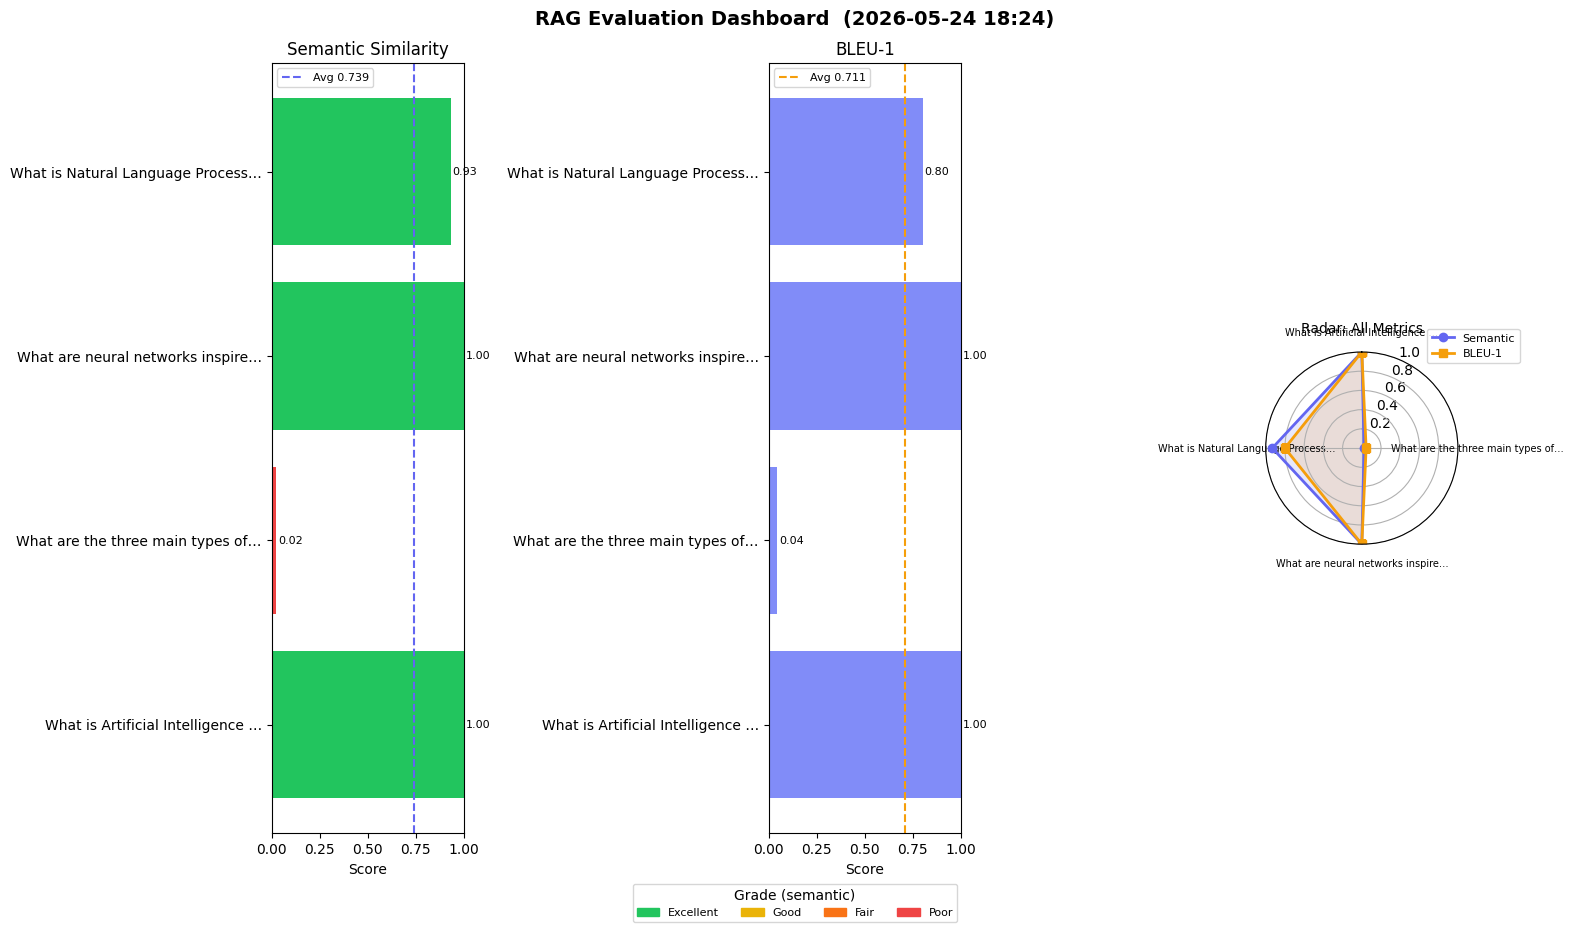

📊 Chart saved to /content/eval_chart.png

📜 Eval history (1 run(s)):
  2026-05-24 18:24  sem=0.739  bleu=0.711  Fair
📄 HTML report saved to /content/eval_report.html


💾 CSV saved to /content/eval_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Cell 10: Evaluation — Auto-Generated Questions + Radar Chart + Run History
import numpy as np
import csv
import datetime
import math
import nltk
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, HTML
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ═══════════════════════════════════════════════════════════════
# STEP 1 — Auto-generate eval Q&A from your actual document
# ═══════════════════════════════════════════════════════════════
# This replaces the old hardcoded eval_set that caused score mismatches.
# Gemini reads sampled chunks from the vector store and writes
# NUM_EVAL_QUESTIONS grounded Q&A pairs automatically.

NUM_EVAL_QUESTIONS = 4   # ← change to generate more/fewer questions

def _auto_generate_eval_set(n: int = NUM_EVAL_QUESTIONS) -> list:
    """Ask Gemini to produce Q&A pairs grounded in the ingested documents."""
    _require_documents()
    all_docs = collection.get(include=["documents"])["documents"]
    step     = max(1, math.ceil(len(all_docs) / 20))
    sampled  = all_docs[::step][:20]
    context  = "\n\n".join(sampled)

    prompt = (
        f"You are creating an evaluation dataset. "
        f"Read the document content below and generate exactly {n} question-answer pairs.\n"
        "Rules:\n"
        "- Each question must be answerable ONLY from the content below.\n"
        "- Each answer must be a single complete sentence.\n"
        "- Return ONLY a JSON array — no preamble, no markdown fences.\n"
        "- Format: [{\"question\": \"...\", \"expected\": \"...\"}]\n\n"
        f"DOCUMENT CONTENT:\n{context}"
    )

    raw = call_gemini(prompt, stream=False)
    # Strip any accidental markdown fences
    raw = raw.strip().lstrip('`').removeprefix('json').strip().rstrip('`').strip()
    try:
        pairs = __import__('json').loads(raw)
        if isinstance(pairs, list) and pairs:
            print(f"✅ Auto-generated {len(pairs)} eval question(s) from document.")
            return pairs
    except Exception as e:
        print(f"⚠️  JSON parse failed ({e}) — falling back to manual eval set.")
    return []


# ── Fallback manual eval set (used only if auto-gen fails) ───────
FALLBACK_EVAL_SET = [
    {
        "question": "What is the main topic of this document?",
        "expected":  "The document covers the main topic described in its introduction."
    },
]

print("🔄 Generating eval questions from your document...")
eval_set = _auto_generate_eval_set(NUM_EVAL_QUESTIONS) or FALLBACK_EVAL_SET
print("\n📋 Eval questions:")
for i, item in enumerate(eval_set):
    print(f"  Q{i+1}: {item['question']}")

# ═══════════════════════════════════════════════════════════════
# STEP 2 — Scoring helpers
# ═══════════════════════════════════════════════════════════════
def semantic_similarity(a: str, b: str) -> float:
    vecs = embedder.encode([a, b])
    return float(np.dot(vecs[0], vecs[1]) / (np.linalg.norm(vecs[0]) * np.linalg.norm(vecs[1])))

def bleu1(reference: str, hypothesis: str) -> float:
    ref = nltk.word_tokenize(reference.lower())
    hyp = nltk.word_tokenize(hypothesis.lower())
    return sentence_bleu([ref], hyp, weights=(1,0,0,0),
                         smoothing_function=SmoothingFunction().method1)

def score_label(s: float) -> str:
    if s >= 0.90: return "Excellent"
    if s >= 0.80: return "Good"
    if s >= 0.70: return "Fair"
    return "Poor"

GRADE_COLOR = {"Excellent": "#22c55e", "Good": "#eab308",
               "Fair": "#f97316", "Poor": "#ef4444"}

# ═══════════════════════════════════════════════════════════════
# STEP 3 — Run evaluation
# ═══════════════════════════════════════════════════════════════
rows = []
print("\nRunning evaluation...")
for item in eval_set:
    predicted = ask(item["question"], show_sources=False, stream=False)
    sem  = semantic_similarity(predicted, item["expected"])
    bleu = bleu1(item["expected"], predicted)
    rows.append({
        "question":  item["question"],
        "expected":  item["expected"],
        "predicted": predicted,
        "semantic":  round(sem,  4),
        "bleu1":     round(bleu, 4),
        "label":     score_label(sem),
    })
    print(f"  ✓ {item['question'][:60]}  → sem={sem:.3f}  bleu={bleu:.3f}")

avg_sem  = float(np.mean([r['semantic'] for r in rows]))
avg_bleu = float(np.mean([r['bleu1']    for r in rows]))
run_ts   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

# ═══════════════════════════════════════════════════════════════
# STEP 4 — Charts: bar charts + radar chart
# ═══════════════════════════════════════════════════════════════
questions_short = [r['question'][:32] + '…' if len(r['question']) > 32
                   else r['question'] for r in rows]
sem_vals  = [r['semantic'] for r in rows]
bleu_vals = [r['bleu1']    for r in rows]
colors    = [GRADE_COLOR[r['label']] for r in rows]

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f"RAG Evaluation Dashboard  ({run_ts})", fontsize=14, fontweight='bold')

# ── Bar chart: Semantic ───────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
bars = ax1.barh(questions_short, sem_vals, color=colors)
ax1.set_xlim(0, 1)
ax1.axvline(avg_sem, color='#6366f1', linestyle='--', linewidth=1.5,
            label=f'Avg {avg_sem:.3f}')
ax1.set_xlabel('Score')
ax1.set_title('Semantic Similarity')
ax1.legend(fontsize=8)
for bar, val in zip(bars, sem_vals):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

# ── Bar chart: BLEU-1 ─────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
bars2 = ax2.barh(questions_short, bleu_vals, color='#818cf8')
ax2.set_xlim(0, 1)
ax2.axvline(avg_bleu, color='#f59e0b', linestyle='--', linewidth=1.5,
            label=f'Avg {avg_bleu:.3f}')
ax2.set_xlabel('Score')
ax2.set_title('BLEU-1')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, bleu_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

# ── Radar chart ───────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3, polar=True)
radar_labels  = questions_short
N             = len(radar_labels)
angles        = [n / float(N) * 2 * math.pi for n in range(N)]
angles        += angles[:1]   # close the loop
sem_radar     = sem_vals  + sem_vals[:1]
bleu_radar    = bleu_vals + bleu_vals[:1]

ax3.set_theta_offset(math.pi / 2)
ax3.set_theta_direction(-1)
ax3.set_thetagrids([a * 180 / math.pi for a in angles[:-1]], radar_labels,
                   fontsize=7, wrap=True)
ax3.plot(angles, sem_radar,  'o-', linewidth=2, color='#6366f1', label='Semantic')
ax3.fill(angles, sem_radar,  alpha=0.15, color='#6366f1')
ax3.plot(angles, bleu_radar, 's-', linewidth=2, color='#f59e0b', label='BLEU-1')
ax3.fill(angles, bleu_radar, alpha=0.15, color='#f59e0b')
ax3.set_ylim(0, 1)
ax3.set_title('Radar: All Metrics', fontsize=10, pad=14)
ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in GRADE_COLOR.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           title='Grade (semantic)', bbox_to_anchor=(0.5, -0.04), fontsize=8)

plt.tight_layout()
chart_path = '/content/eval_chart.png'
plt.savefig(chart_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'📊 Chart saved to {chart_path}')

# ═══════════════════════════════════════════════════════════════
# STEP 5 — Eval history (persist across runs in /content)
# ═══════════════════════════════════════════════════════════════
import json as _json, pathlib

history_path = pathlib.Path('/content/eval_history.json')
if history_path.exists():
    eval_history = _json.loads(history_path.read_text())
else:
    eval_history = []

eval_history.append({
    "run":      run_ts,
    "avg_sem":  round(avg_sem,  4),
    "avg_bleu": round(avg_bleu, 4),
    "grade":    score_label(avg_sem),
    "n_questions": len(rows),
})
history_path.write_text(_json.dumps(eval_history, indent=2))
print(f"\n📜 Eval history ({len(eval_history)} run(s)):")
for h in eval_history:
    print(f"  {h['run']}  sem={h['avg_sem']:.3f}  bleu={h['avg_bleu']:.3f}  {h['grade']}")

# ═══════════════════════════════════════════════════════════════
# STEP 6 — HTML report
# ═══════════════════════════════════════════════════════════════
import base64
chart_b64 = base64.b64encode(pathlib.Path(chart_path).read_bytes()).decode()

def _grade_badge(label):
    c = GRADE_COLOR[label]
    return (f'<span style="background:{c};color:#fff;padding:2px 8px;'
            f'border-radius:4px;font-size:0.8em;font-weight:bold;">{label}</span>')

rows_html = ""
for i, r in enumerate(rows):
    rows_html += f"""
    <details style='margin:10px 0;border:1px solid #e2e8f0;border-radius:8px;'>
      <summary style='padding:12px 16px;cursor:pointer;background:#f8fafc;
                      border-radius:8px;font-weight:600;'>
        Q{i+1}: {r['question']}
        &nbsp;&nbsp;Semantic: <b>{r['semantic']}</b> {_grade_badge(r['label'])}
        &nbsp;&nbsp;BLEU-1: <b>{r['bleu1']}</b>
      </summary>
      <div style='padding:14px 18px;'>
        <p><b>Expected:</b> {r['expected']}</p>
        <p><b>Got:</b> {r['predicted']}</p>
      </div>
    </details>"""

history_rows = "".join(
    f"<tr><td>{h['run']}</td><td>{h['avg_sem']:.3f}</td>"
    f"<td>{h['avg_bleu']:.3f}</td><td>{h['n_questions']}</td>"
    f"<td>{_grade_badge(h['grade'])}</td></tr>"
    for h in eval_history
)

html_report = f"""
<!DOCTYPE html><html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>RAG Eval Report — {run_ts}</title>
  <style>
    body{{font-family:system-ui,sans-serif;max-width:980px;margin:40px auto;padding:0 20px;color:#1e293b;}}
    h1{{font-size:1.6em;border-bottom:3px solid #6366f1;padding-bottom:8px;}}
    h2{{margin-top:2em;color:#334155;}}
    .grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin:24px 0;}}
    .card{{background:#f8fafc;border:1px solid #e2e8f0;border-radius:10px;padding:18px;text-align:center;}}
    .card .value{{font-size:2em;font-weight:800;color:#6366f1;}}
    .card .metric{{font-size:0.85em;color:#64748b;margin-top:4px;}}
    table{{width:100%;border-collapse:collapse;margin-top:12px;}}
    th,td{{padding:10px 12px;text-align:left;border-bottom:1px solid #e2e8f0;}}
    th{{background:#f1f5f9;font-weight:600;}}
  </style>
</head>
<body>
  <h1>📊 RAG Evaluation Report</h1>
  <p style='color:#64748b'>Generated: {run_ts} &nbsp;|&nbsp; {len(rows)} questions</p>
  <div class='grid'>
    <div class='card'><div class='value'>{avg_sem:.3f}</div><div class='metric'>Avg Semantic</div></div>
    <div class='card'><div class='value'>{avg_bleu:.3f}</div><div class='metric'>Avg BLEU-1</div></div>
    <div class='card'><div class='value'>{len(rows)}</div><div class='metric'>Questions</div></div>
    <div class='card'><div class='value' style='font-size:1.4em'>{score_label(avg_sem)}</div><div class='metric'>Grade</div></div>
  </div>
  <h2>Charts</h2>
  <img src='data:image/png;base64,{chart_b64}' style='width:100%;border-radius:8px;'>
  <h2>Per-Question Results</h2>
  {rows_html}
  <h2>📜 Eval Run History</h2>
  <table>
    <tr><th>Run</th><th>Avg Semantic</th><th>Avg BLEU-1</th><th>Questions</th><th>Grade</th></tr>
    {history_rows}
  </table>
</body></html>"""

html_path = '/content/eval_report.html'
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_report)
print(f'📄 HTML report saved to {html_path}')

# Inline summary cards
display(HTML(f"""
<div style='display:flex;gap:16px;margin:16px 0;flex-wrap:wrap;'>
  <div style='background:#f0f9ff;border:1px solid #bae6fd;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#0ea5e9'>{avg_sem:.3f}</div>
    <div style='color:#64748b;font-size:0.85em'>Avg Semantic</div></div>
  <div style='background:#faf5ff;border:1px solid #e9d5ff;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#a855f7'>{avg_bleu:.3f}</div>
    <div style='color:#64748b;font-size:0.85em'>Avg BLEU-1</div></div>
  <div style='background:#f0fdf4;border:1px solid #bbf7d0;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#22c55e'>{score_label(avg_sem)}</div>
    <div style='color:#64748b;font-size:0.85em'>Grade</div></div>
</div>"""))

# CSV export + auto-download
csv_path = '/content/eval_results.csv'
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['question','expected','predicted','semantic','bleu1','label'])
    writer.writeheader()
    writer.writerows(rows)
print(f'💾 CSV saved to {csv_path}')
try:
    from google.colab import files as _cf
    for p in [csv_path, html_path, chart_path]:
        _cf.download(p)
except Exception:
    pass